In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/retail_features.csv')

In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
df.head()
df.shape
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0
Year,0


In [5]:
cohort = df.groupby('CustomerID')['InvoiceDate'].min().reset_index()
cohort.columns = ['CustomerID','CohortDate']

In [6]:
cohort['CohortMonth'] = cohort['CohortDate'].dt.to_period('M')

In [7]:
df = df.merge(
    cohort[['CustomerID','CohortMonth']],
    on='CustomerID',
    how='left'
)

In [8]:
df['TransactionMonth'] = (
    df['InvoiceDate']
      .dt.to_period('M')
)

In [9]:
df[['CustomerID',
    'CohortMonth',
    'TransactionMonth']].head()

,CustomerID,CohortMonth,TransactionMonth
0,17850.0,2010-12,2010-12
1,17850.0,2010-12,2010-12
2,17850.0,2010-12,2010-12
3,17850.0,2010-12,2010-12
4,17850.0,2010-12,2010-12


In [10]:
year_diff = (
    df['TransactionMonth'].dt.year
    -
    df['CohortMonth'].dt.year
)

month_diff = (
    df['TransactionMonth'].dt.month
    -
    df['CohortMonth'].dt.month
)

df['CohortIndex'] = (
    year_diff * 12
    + month_diff
)

In [11]:
df[['CustomerID',
    'CohortMonth',
    'TransactionMonth',
    'CohortIndex']].head(20)

,CustomerID,CohortMonth,TransactionMonth,CohortIndex
0,17850.0,2010-12,2010-12,0
1,17850.0,2010-12,2010-12,0
2,17850.0,2010-12,2010-12,0
3,17850.0,2010-12,2010-12,0
4,17850.0,2010-12,2010-12,0
5,17850.0,2010-12,2010-12,0
6,17850.0,2010-12,2010-12,0
7,17850.0,2010-12,2010-12,0
8,17850.0,2010-12,2010-12,0
9,13047.0,2010-12,2010-12,0


In [12]:
cohort_data = (
    df.groupby(
        ['CohortMonth','CohortIndex']
    )['CustomerID']
    .nunique()
    .reset_index()
)

In [13]:
cohort_counts = (
    cohort_data.pivot(
        index='CohortMonth',
        columns='CohortIndex',
        values='CustomerID'
    )
)

In [14]:
cohort_counts.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN


In [15]:
cohort_size = cohort_counts.iloc[:,0]

In [16]:
retention = (
    cohort_counts
    .divide(cohort_size, axis=0)
    * 100
)

In [17]:
retention = retention.round(1)

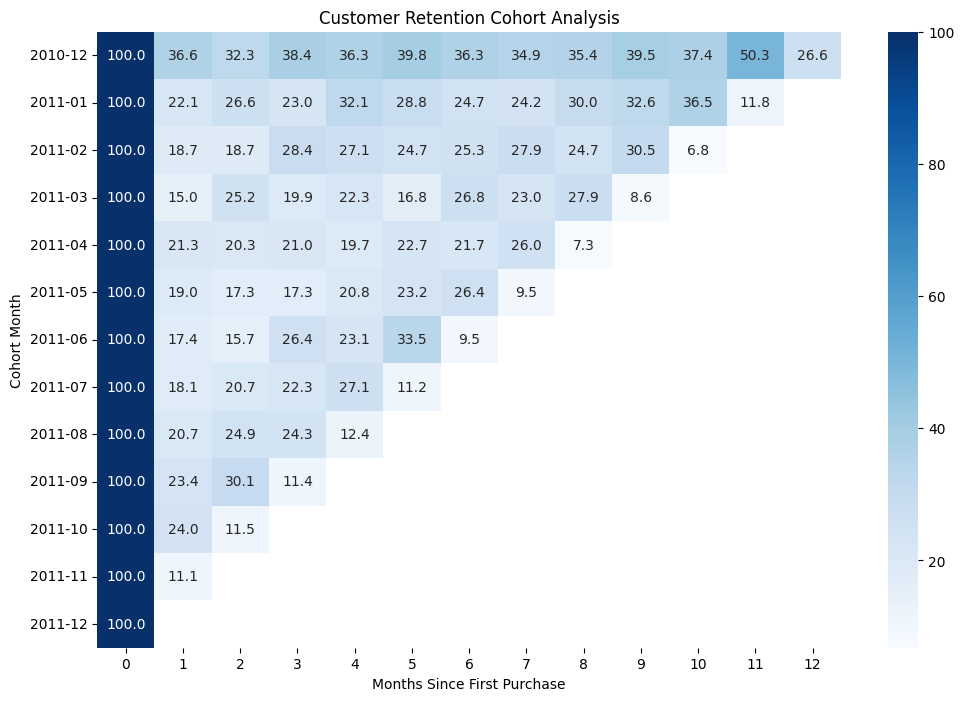

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Customer Retention Cohort Analysis')

plt.ylabel('Cohort Month')

plt.xlabel('Months Since First Purchase')

plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/cohort_retention_heatmap.png',
    bbox_inches='tight'
)

plt.show()

In [19]:
avg_retention = retention.mean()

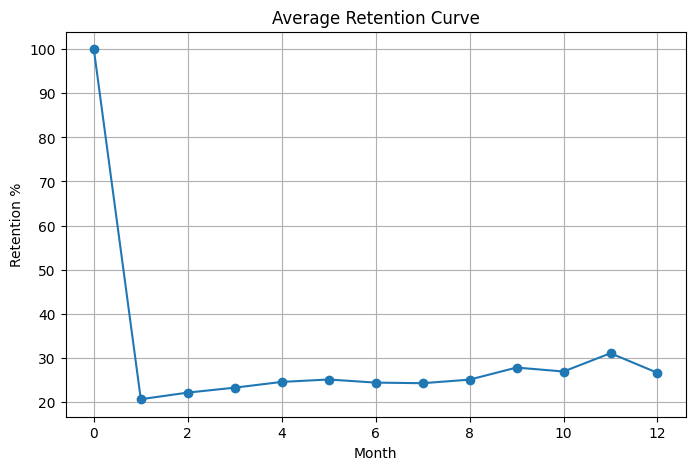

In [20]:
plt.figure(figsize=(8,5))

avg_retention.plot(marker='o')

plt.title('Average Retention Curve')

plt.xlabel('Month')

plt.ylabel('Retention %')

plt.grid(True)

plt.show()

In [22]:
revenue_cohort = (
    df.groupby(
        ['CohortMonth','CohortIndex']
    )['Revenue']
    .sum()
    .reset_index()
)

In [24]:
revenue_matrix = revenue_cohort.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Revenue'
)

In [25]:
base_revenue = revenue_matrix.iloc[:,0]

revenue_retention = (
    revenue_matrix
    .divide(base_revenue, axis=0)
    * 100
)

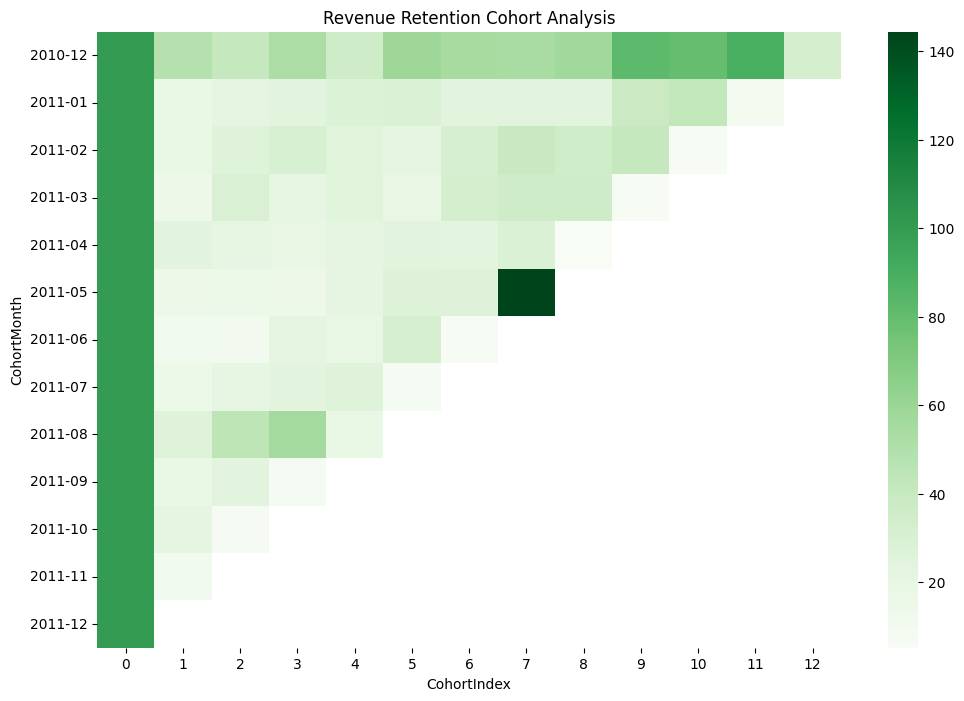

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(
    revenue_retention,
    annot=False,
    cmap='Greens'
)

plt.title('Revenue Retention Cohort Analysis')

plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/revenue_retention_heatmap.png',
    bbox_inches='tight'
)

plt.show()

In [27]:
retention.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/cohort_retention.csv'
)

In [28]:
revenue_retention.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/revenue_retention.csv'
)